# Explainable and Fair Recidivism Prediction Using Machine Learning

**A Responsible AI Case Study on the ProPublica COMPAS Dataset**

---

This notebook builds, explains, and audits machine learning models that predict whether a defendant will re-offend within two years, using the dataset made public by ProPublica in its 2016 investigation of the COMPAS risk-assessment tool.

The project is organized into the following sections:

1. Introduction
2. Imports
3. Data Loading
4. Data Cleaning
5. Exploratory Data Analysis
6. Feature Engineering
7. Baseline Modeling
8. Advanced Modeling
9. Class Imbalance
10. Explainability (SHAP)
11. Fairness Analysis (Fairlearn)
12. Responsible AI Discussion
13. Results
14. Discussion
15. Limitations
16. Future Work
17. Conclusion
18. Executive Summary & Portfolio Write-up

> **Note:** This notebook is built for educational and portfolio purposes. It is *not* intended to be deployed as a real-world risk-assessment system. See the Responsible AI section for a discussion of why.


## 1. Introduction

### What is recidivism prediction?

Recidivism prediction refers to the use of statistical or machine learning models to estimate the likelihood that a person who has been arrested or convicted will re-offend within a given time period (commonly two years). These models are used by some courts and parole boards in the United States to inform decisions such as bail, sentencing, and parole.

### Why does it matter?

These predictions can directly influence a person's liberty. A model that systematically over-predicts risk for one group, or under-predicts it for another, can contribute to unequal treatment under the law — even if no individual decision-maker intends to discriminate.

### The COMPAS controversy

COMPAS (Correctional Offender Management Profiling for Alternative Sanctions) is a proprietary risk-assessment tool that has been used in several U.S. states. In 2016, journalists at ProPublica published an analysis arguing that COMPAS was substantially more likely to falsely flag Black defendants as high risk, and substantially more likely to falsely flag white defendants as low risk, even though overall accuracy was similar across groups. Northpointe (the company behind COMPAS) disputed this analysis, arguing that the tool was well-calibrated within each group. This disagreement turned out to be a foundational case study in algorithmic fairness: it is mathematically impossible, except in special cases, to simultaneously satisfy calibration *and* equalized error rates when base rates differ between groups. This notebook revisits that dataset using modern, open-source tooling.

### Ethical concerns and Responsible AI considerations

* **Disparate impact**: a model can be biased even if it never uses race as an input feature directly, because other features (such as priors or zip code) can act as proxies.
* **Accuracy is not enough**: a highly accurate model can still be deeply unfair if its errors are unevenly distributed across groups.
* **Human-in-the-loop**: predictive tools should support, not replace, human judgment in high-stakes legal decisions.
* **Transparency**: explainability tools (like SHAP) make it possible to audit *why* a model made a prediction, which is essential for due process and accountability.

This notebook treats predictive performance, explainability, and fairness as three co-equal objectives rather than treating fairness as an afterthought.


## 2. Imports and Environment Setup

We install and import all libraries needed for modeling, explainability, and fairness analysis. We also fix random seeds throughout the notebook for reproducibility.


In [1]:
# Install packages not pre-installed on Colab (safe to re-run)
!pip install -q xgboost lightgbm shap fairlearn imbalanced-learn --upgrade


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 3.4 MB/s eta 0:00:00


In [2]:
import os
import warnings
import random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay, average_precision_score
)

import xgboost as xgb
import lightgbm as lgb

from imblearn.over_sampling import SMOTE

import shap

from fairlearn.metrics import (
    MetricFrame, demographic_parity_difference, equalized_odds_difference,
    selection_rate, false_positive_rate, false_negative_rate, true_positive_rate
)

warnings.filterwarnings("ignore")

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# -----------------------------
# Plot styling
# -----------------------------
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13

PALETTE = "viridis"

print("Environment ready. Random seed:", SEED)


Environment ready. Random seed: 42


## 3. Data Loading

We use the `compas-scores-two-years.csv` file from ProPublica's public GitHub repository, which is the standard dataset used in the original ProPublica analysis and in most subsequent academic fairness research.

The cell below attempts an automatic download. If the automatic download fails (e.g. due to network restrictions in your Colab session), a manual upload cell is provided immediately below it as a fallback — just run the upload cell and select the CSV file.


In [3]:
DATA_URL = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
LOCAL_PATH = "compas-scores-two-years.csv"

download_success = False
try:
    df_raw = pd.read_csv(DATA_URL)
    df_raw.to_csv(LOCAL_PATH, index=False)
    download_success = True
    print(f"Downloaded dataset directly from ProPublica GitHub: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns.")
except Exception as e:
    print("Automatic download failed with error:")
    print(e)
    print("\nPlease run the manual upload cell below.")


Downloaded dataset directly from ProPublica GitHub: 7214 rows, 53 columns.


**Fallback: manual upload (only run this if the automatic download above failed).**

Download the file manually from
[propublica/compas-analysis](https://github.com/propublica/compas-analysis/blob/master/compas-scores-two-years.csv)
and upload it using the cell below.


In [4]:
if not download_success:
    from google.colab import files
    print("Please select 'compas-scores-two-years.csv' to upload.")
    uploaded = files.upload()
    LOCAL_PATH = list(uploaded.keys())[0]
    df_raw = pd.read_csv(LOCAL_PATH)
    print(f"Loaded uploaded dataset: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns.")

df_raw.head()


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


In [5]:
print("Columns available in raw dataset:")
print(list(df_raw.columns))


Columns available in raw dataset:
['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob', 'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score', 'juv_misd_count', 'juv_other_count', 'priors_count', 'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number', 'c_offense_date', 'c_arrest_date', 'c_days_from_compas', 'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number', 'r_charge_degree', 'r_days_from_arrest', 'r_offense_date', 'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid', 'is_violent_recid', 'vr_case_number', 'vr_charge_degree', 'vr_offense_date', 'vr_charge_desc', 'type_of_assessment', 'decile_score.1', 'score_text', 'screening_date', 'v_type_of_assessment', 'v_decile_score', 'v_score_text', 'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1', 'start', 'end', 'event', 'two_year_recid']


## 4. Data Cleaning

We follow the filtering logic from ProPublica's original analysis, which restricts the data to records where the COMPAS score could plausibly correspond to the charge being assessed. Specifically, we keep only the columns relevant to this project and apply the standard ProPublica filters:

* The charge date of the arrest occurring within 30 days of when the person was screened, to remove cases where we might not have the right offense.
* Remove rows with `is_recid == -1` (no recidivism data available).
* Remove traffic-related offenses (`c_charge_degree == 'O'`), which carry no jail time.
* Remove rows where `score_text == 'N/A'`.

We then check for missing values, duplicates, and obvious outliers, and correct data types.


In [6]:
cols_of_interest = [
    "age", "age_cat", "sex", "race", "priors_count",
    "juv_fel_count", "juv_misd_count", "juv_other_count",
    "c_charge_degree", "score_text", "two_year_recid",
    "days_b_screening_arrest", "is_recid", "c_jail_in", "c_jail_out"
]

available_cols = [c for c in cols_of_interest if c in df_raw.columns]
df = df_raw[available_cols].copy()

print("Rows before ProPublica-standard filtering:", len(df))

if "days_b_screening_arrest" in df.columns:
    df = df[(df["days_b_screening_arrest"] <= 30) & (df["days_b_screening_arrest"] >= -30)]
if "is_recid" in df.columns:
    df = df[df["is_recid"] != -1]
if "c_charge_degree" in df.columns:
    df = df[df["c_charge_degree"] != "O"]
if "score_text" in df.columns:
    df = df[df["score_text"] != "N/A"]

print("Rows after ProPublica-standard filtering:", len(df))


Rows before ProPublica-standard filtering: 7214
Rows after ProPublica-standard filtering: 6172


In [7]:
# Drop helper columns no longer needed for modeling
drop_helper = [c for c in ["days_b_screening_arrest", "is_recid", "c_jail_in", "c_jail_out"] if c in df.columns]
df = df.drop(columns=drop_helper)

df = df.rename(columns={"c_charge_degree": "charge_degree"})

df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              6172 non-null   int64 
 1   age_cat          6172 non-null   object
 2   sex              6172 non-null   object
 3   race             6172 non-null   object
 4   priors_count     6172 non-null   int64 
 5   juv_fel_count    6172 non-null   int64 
 6   juv_misd_count   6172 non-null   int64 
 7   juv_other_count  6172 non-null   int64 
 8   charge_degree    6172 non-null   object
 9   score_text       6172 non-null   object
 10  two_year_recid   6172 non-null   int64 
dtypes: int64(6), object(5)
memory usage: 578.6+ KB


In [8]:
# Missing value analysis
missing_summary = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing_summary / len(df) * 100).round(2)
missing_table = pd.DataFrame({"missing_count": missing_summary, "missing_pct": missing_pct})
missing_table = missing_table[missing_table["missing_count"] > 0]
print("Missing value summary:")
missing_table


Missing value summary:


,missing_count,missing_pct


If any columns show missing values above, we drop rows with missing target/key demographic values (a small fraction of the data) since imputing demographic attributes used in a fairness audit would be inappropriate.

In [9]:
before = len(df)
df = df.dropna(subset=["age", "sex", "race", "priors_count", "charge_degree", "score_text", "two_year_recid"])
after = len(df)
print(f"Dropped {before - after} rows with missing key values ({(before-after)/before*100:.2f}%).")

# Duplicate check
n_dupes = df.duplicated().sum()
print(f"Duplicate rows found: {n_dupes}")
df = df.drop_duplicates()
print(f"Rows after de-duplication: {len(df)}")


Dropped 0 rows with missing key values (0.00%).
Duplicate rows found: 1737
Rows after de-duplication: 4435


In [10]:
# Outlier inspection on numeric columns
numeric_cols = ["age", "priors_count", "juv_fel_count", "juv_misd_count", "juv_other_count"]
display(df[numeric_cols].describe().T)

# Cap obviously implausible ages (data entry errors), if any
df = df[(df["age"] >= 18) & (df["age"] <= 100)]
print("Final cleaned dataset shape:", df.shape)


,count,mean,std,min,25%,50%,75%,max
age,4435.0,35.409921,11.996079,18.0,26.0,32.0,43.0,96.0
priors_count,4435.0,4.113867,5.208583,0.0,1.0,2.0,6.0,38.0
juv_fel_count,4435.0,0.081849,0.544644,0.0,0.0,0.0,0.0,20.0
juv_misd_count,4435.0,0.125817,0.582754,0.0,0.0,0.0,0.0,13.0
juv_other_count,4435.0,0.147463,0.543456,0.0,0.0,0.0,0.0,9.0


Final cleaned dataset shape: (4435, 11)


In [11]:
# Data type correction
df["two_year_recid"] = df["two_year_recid"].astype(int)
for c in ["age", "priors_count", "juv_fel_count", "juv_misd_count", "juv_other_count"]:
    df[c] = pd.to_numeric(df[c], errors="coerce").astype(int)
for c in ["age_cat", "sex", "race", "charge_degree", "score_text"]:
    df[c] = df[c].astype("category")

print("Final dtypes:")
df.dtypes


Final dtypes:


,0
age,int64
age_cat,category
sex,category
race,category
priors_count,int64
juv_fel_count,int64
juv_misd_count,int64
juv_other_count,int64
charge_degree,category
score_text,category


## 5. Exploratory Data Analysis

We now explore the cleaned dataset, focusing on the target distribution, demographic breakdowns, and the relationships between key numeric features.


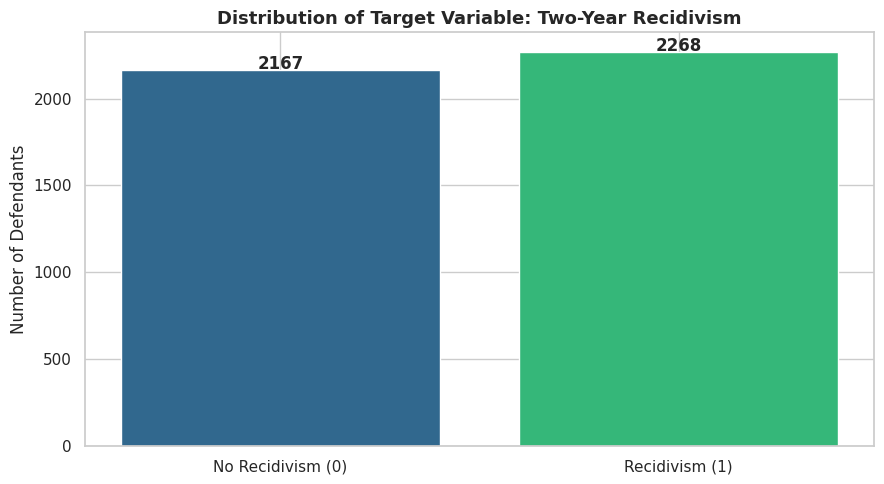

Overall recidivism rate: 51.1%


In [12]:
fig, ax = plt.subplots()
counts = df["two_year_recid"].value_counts().sort_index()
bars = ax.bar(["No Recidivism (0)", "Recidivism (1)"], counts.values, color=sns.color_palette(PALETTE, 2))
ax.set_title("Distribution of Target Variable: Two-Year Recidivism")
ax.set_ylabel("Number of Defendants")
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, v + 5, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Overall recidivism rate: {df['two_year_recid'].mean()*100:.1f}%")


**Interpretation:** The two classes are reasonably balanced (roughly 45-55%), so severe class imbalance is unlikely to be a major issue, though we verify and address it formally later.

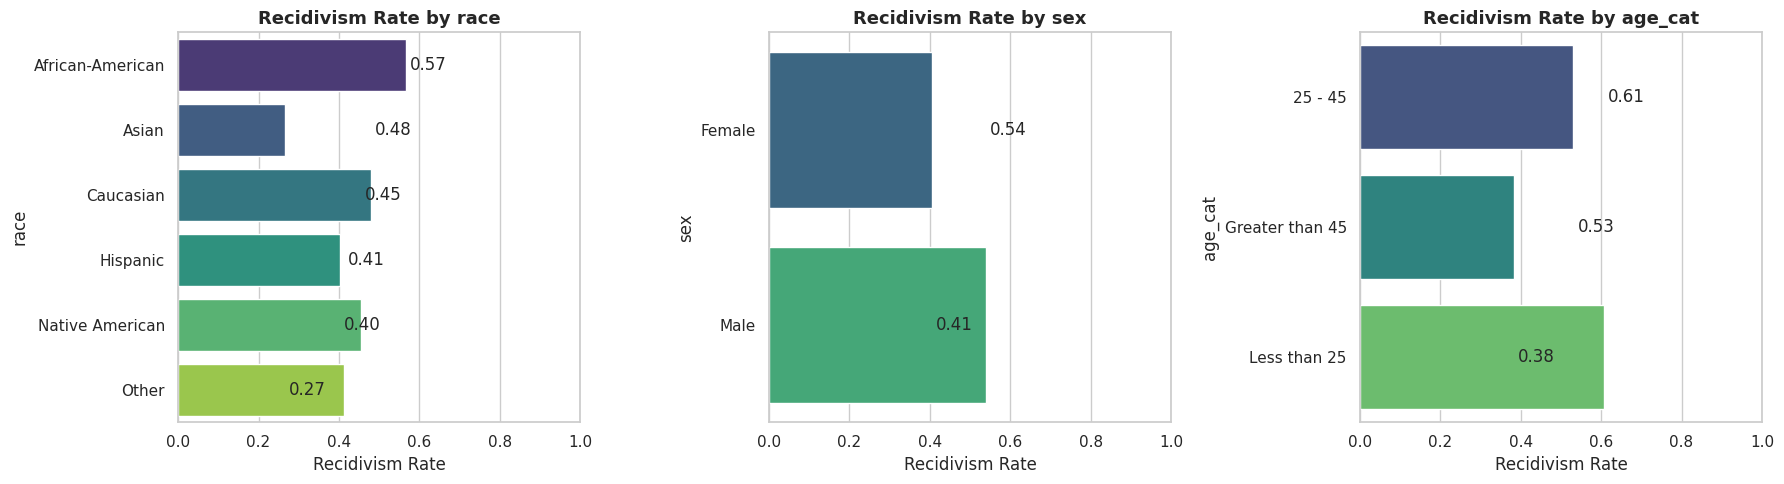

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, group in zip(axes, ["race", "sex", "age_cat"]):
    rates = df.groupby(group)["two_year_recid"].mean().sort_values(ascending=False)
    sns.barplot(x=rates.values, y=rates.index, ax=ax, palette=PALETTE)
    ax.set_title(f"Recidivism Rate by {group}")
    ax.set_xlabel("Recidivism Rate")
    ax.set_xlim(0, 1)
    for i, v in enumerate(rates.values):
        ax.text(v + 0.01, i, f"{v:.2f}", va="center")

plt.tight_layout()
plt.show()


**Interpretation:** Recidivism rates differ noticeably across race, sex, and age categories. Younger defendants and male defendants show higher recidivism rates, and there is a visible gap between racial groups. These raw rate differences reflect real disparities in the underlying population captured by the criminal justice system — they do **not** by themselves imply anything about an individual's risk, and they motivate the fairness analysis later in this notebook, since a model trained on this data can easily learn and amplify these patterns.

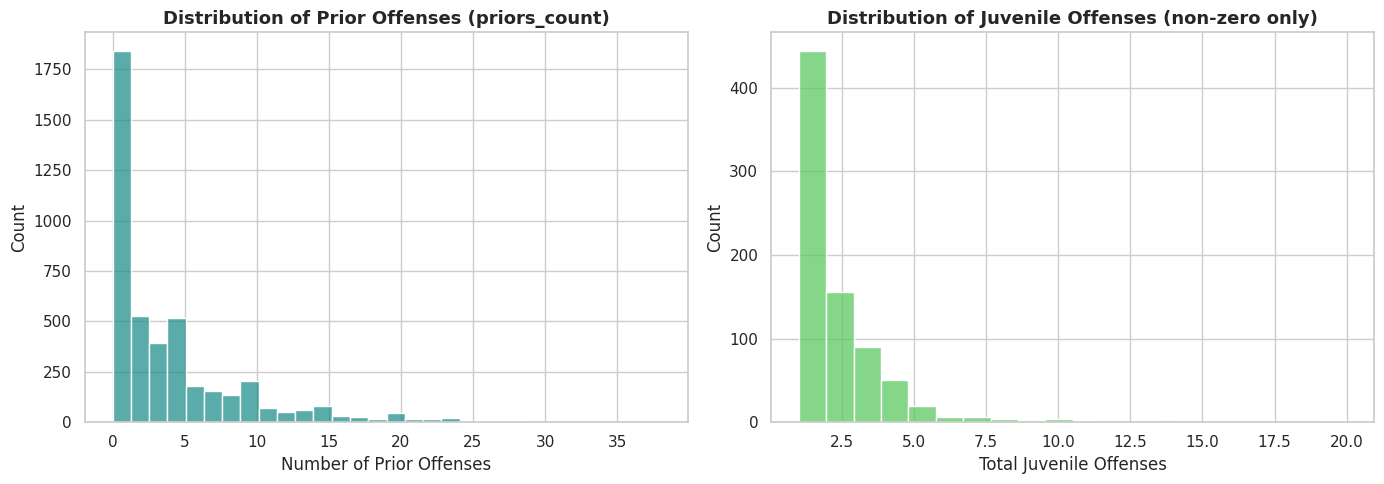

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["priors_count"], bins=30, kde=False, ax=axes[0], color=sns.color_palette(PALETTE, 1)[0])
axes[0].set_title("Distribution of Prior Offenses (priors_count)")
axes[0].set_xlabel("Number of Prior Offenses")

juv_total = df["juv_fel_count"] + df["juv_misd_count"] + df["juv_other_count"]
sns.histplot(juv_total[juv_total > 0], bins=20, ax=axes[1], color=sns.color_palette(PALETTE, 3)[2])
axes[1].set_title("Distribution of Juvenile Offenses (non-zero only)")
axes[1].set_xlabel("Total Juvenile Offenses")

plt.tight_layout()
plt.show()


**Interpretation:** `priors_count` is heavily right-skewed — most defendants have few or no prior offenses, but a long tail has many. Juvenile offense counts are mostly zero; among defendants with at least one juvenile offense, the distribution is also right-skewed. These skewed distributions suggest tree-based models (which are robust to skew and outliers) may perform at least as well as linear models here.

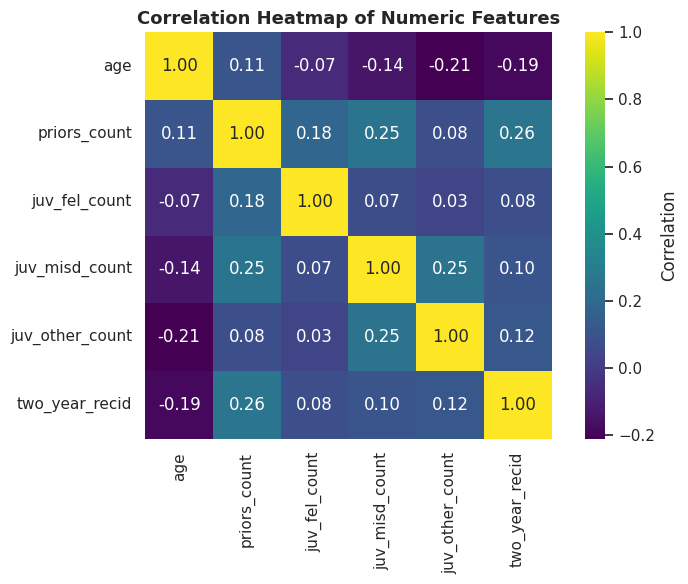

In [15]:
numeric_for_corr = ["age", "priors_count", "juv_fel_count", "juv_misd_count", "juv_other_count", "two_year_recid"]
corr = df[numeric_for_corr].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap=PALETTE, square=True, ax=ax, cbar_kws={"label": "Correlation"})
ax.set_title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()


**Interpretation:** `priors_count` shows the strongest positive correlation with `two_year_recid` among the numeric features, which aligns with criminological research showing prior offense history is one of the strongest predictors of future offending. Juvenile offense counts show weaker but positive correlations. Age is negatively correlated, consistent with the well-established "age-crime curve.


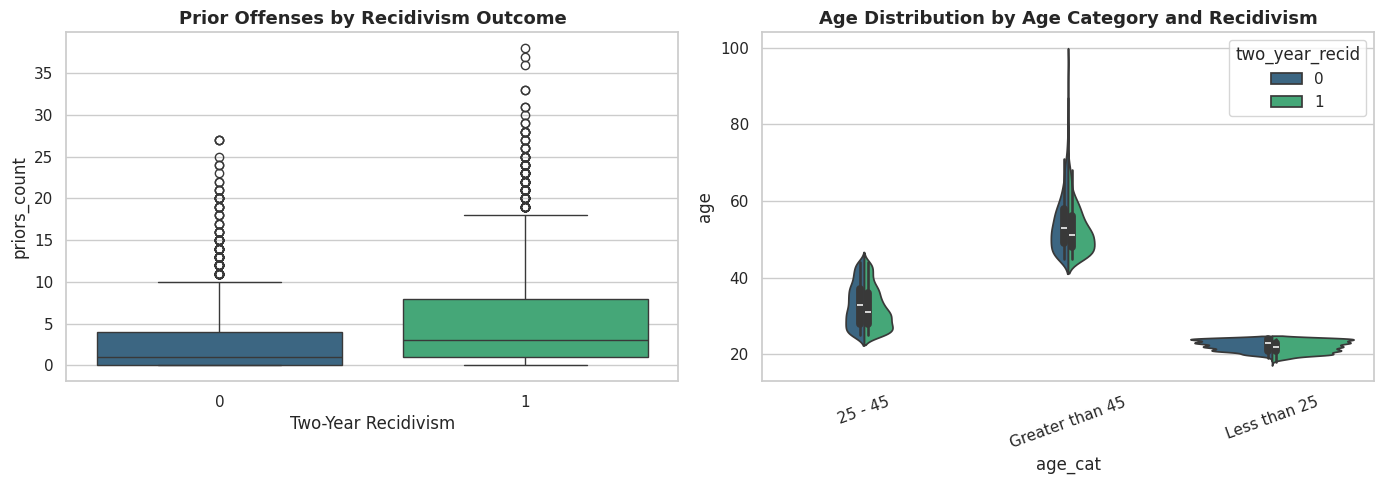

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="two_year_recid", y="priors_count", ax=axes[0], palette=PALETTE)
axes[0].set_title("Prior Offenses by Recidivism Outcome")
axes[0].set_xlabel("Two-Year Recidivism")

sns.violinplot(data=df, x="age_cat", y="age", hue="two_year_recid", split=True, ax=axes[1], palette=PALETTE)
axes[1].set_title("Age Distribution by Age Category and Recidivism")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


**Interpretation:** Defendants who recidivated within two years tend to have more prior offenses on average, and within every age category, recidivism skews toward the younger end of that category's age range. These patterns give us confidence that `priors_count` and `age` will be informative features for modeling.

## 6. Feature Engineering

We now prepare the data for modeling:

* Separate features (`X`) from the target (`y`).
* Keep `race` and `sex` aside as sensitive attributes for the fairness analysis (not used in `X` is a design choice some practitioners make; here we evaluate **both** a version with and a version without these attributes is out of scope for a single notebook, so to match the original COMPAS setup — where race is *not* an explicit model input but is used for the fairness audit — we exclude `race` from the model features but retain `sex`, `age`, and criminal-history features as inputs, consistent with the variables Northpointe states COMPAS itself does not use as direct race indicators).
* One-hot encode categorical variables.
* Split into train / validation / test sets (70/15/15) using **stratified sampling** on the target.
* Scale numeric features (fit on train only, to prevent data leakage).


In [17]:
target_col = "two_year_recid"
sensitive_cols = ["race", "sex"]

feature_cols = [c for c in df.columns if c not in [target_col, "race"]]  # race excluded from model inputs
X = df[feature_cols].copy()
y = df[target_col].copy()

# Keep sensitive attributes aligned by index for later fairness evaluation
sensitive_df = df[sensitive_cols].copy()

categorical_features = ["age_cat", "sex", "charge_degree", "score_text"]
numeric_features = ["age", "priors_count", "juv_fel_count", "juv_misd_count", "juv_other_count"]

print("Model input features:", feature_cols)
print("Sensitive attributes (held out, used only for fairness evaluation):", sensitive_cols)


Model input features: ['age', 'age_cat', 'sex', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'charge_degree', 'score_text']
Sensitive attributes (held out, used only for fairness evaluation): ['race', 'sex']


In [18]:
# 70/15/15 stratified split
X_train, X_temp, y_train, y_temp, sens_train, sens_temp = train_test_split(
    X, y, sensitive_df, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test, sens_val, sens_test = train_test_split(
    X_temp, y_temp, sens_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f"Train: {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Val:   {X_val.shape[0]} rows ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test:  {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.1f}%)")


Train: 3104 rows (70.0%)
Val:   665 rows (15.0%)
Test:  666 rows (15.0%)


In [19]:
# Preprocessing pipeline: one-hot encode categoricals, scale numerics.
# Fit ONLY on training data to avoid leakage; transform val/test using the fitted preprocessor.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), categorical_features),
    ]
)

preprocessor.fit(X_train)

def transform(Xsplit):
    arr = preprocessor.transform(Xsplit)
    cols = (numeric_features +
            list(preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)))
    return pd.DataFrame(arr, columns=cols, index=Xsplit.index)

X_train_t = transform(X_train)
X_val_t = transform(X_val)
X_test_t = transform(X_test)

print("Transformed feature matrix shape (train):", X_train_t.shape)
X_train_t.head()


Transformed feature matrix shape (train): (3104, 13)


,age,priors_count,juv_fel_count,juv_misd_count,juv_other_count,age_cat_25 - 45,age_cat_Greater than 45,age_cat_Less than 25,sex_Male,charge_degree_M,score_text_High,score_text_Low,score_text_Medium
6682,-0.702802,-0.793453,-0.177107,-0.210073,-0.260279,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
5509,-0.619754,2.647121,-0.177107,1.338781,-0.260279,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1264,-1.034993,-0.028881,-0.177107,-0.210073,-0.260279,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
2403,-0.204516,0.735691,-0.177107,-0.210073,-0.260279,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3957,0.958152,-0.602310,-0.177107,-0.210073,-0.260279,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0


## 7. Reusable Evaluation & Plotting Functions

To keep the rest of the notebook modular and DRY, we define reusable helper functions for evaluation, ROC/PR plotting, confusion matrices, and fairness metrics, which we will call repeatedly throughout the remaining sections.


In [20]:
results_table = []  # collects metrics for every model we train

def evaluate_model(name, model, X_eval, y_eval, store=True):
    """Compute standard classification metrics for a fitted model."""
    y_pred = model.predict(X_eval)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_eval)[:, 1]
    else:
        y_proba = model.decision_function(X_eval)

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_eval, y_pred),
        "Precision": precision_score(y_eval, y_pred),
        "Recall": recall_score(y_eval, y_pred),
        "F1": f1_score(y_eval, y_pred),
        "ROC-AUC": roc_auc_score(y_eval, y_proba),
    }
    if store:
        results_table.append(metrics)
    return metrics, y_pred, y_proba


def plot_confusion(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4.5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Recid", "Recid"])
    disp.plot(ax=ax, cmap=PALETTE, colorbar=False)
    ax.set_title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.show()


def plot_roc_curves(models_dict, X_eval, y_eval):
    fig, ax = plt.subplots(figsize=(7, 6))
    for name, model in models_dict.items():
        proba = model.predict_proba(X_eval)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_eval)
        fpr, tpr, _ = roc_curve(y_eval, proba)
        auc = roc_auc_score(y_eval, proba)
        ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", linewidth=2)
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Chance")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve Comparison")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


def plot_pr_curves(models_dict, X_eval, y_eval):
    fig, ax = plt.subplots(figsize=(7, 6))
    for name, model in models_dict.items():
        proba = model.predict_proba(X_eval)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_eval)
        prec, rec, _ = precision_recall_curve(y_eval, proba)
        ap = average_precision_score(y_eval, proba)
        ax.plot(rec, prec, label=f"{name} (AP = {ap:.3f})", linewidth=2)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Precision-Recall Curve Comparison")
    ax.legend(loc="lower left")
    plt.tight_layout()
    plt.show()


def compute_fairness_metrics(y_true, y_pred, sensitive_feature):
    """Return a MetricFrame and a flat summary DataFrame for one sensitive attribute."""
    metric_fns = {
        "selection_rate": selection_rate,
        "false_positive_rate": false_positive_rate,
        "false_negative_rate": false_negative_rate,
        "true_positive_rate": true_positive_rate,
        "accuracy": accuracy_score,
    }
    mf = MetricFrame(metrics=metric_fns, y_true=y_true, y_pred=y_pred, sensitive_features=sensitive_feature)
    dpd = demographic_parity_difference(y_true, y_pred, sensitive_features=sensitive_feature)
    eod = equalized_odds_difference(y_true, y_pred, sensitive_features=sensitive_feature)
    return mf, dpd, eod

print("Helper functions defined.")


Helper functions defined.


## 8. Baseline Modeling: Logistic Regression

We start with a simple, interpretable baseline: logistic regression. This gives us a performance floor to compare more complex models against, and its coefficients offer an initial (if crude) view into feature relationships.


In [21]:
log_reg = LogisticRegression(max_iter=1000, random_state=SEED)
log_reg.fit(X_train_t, y_train)

lr_metrics, lr_pred, lr_proba = evaluate_model("Logistic Regression", log_reg, X_val_t, y_val)
pd.DataFrame([lr_metrics])


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.646617,0.666667,0.617647,0.641221,0.712557


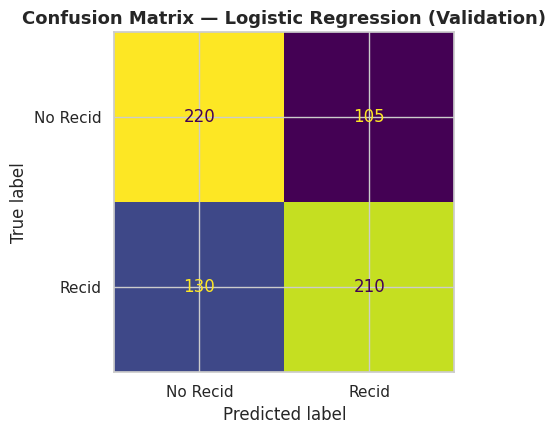

In [22]:
plot_confusion("Logistic Regression (Validation)", y_val, lr_pred)


**Interpretation:** Logistic regression provides a reasonable baseline. We now move on to tree-based ensemble models, which typically handle the skewed, non-linear relationships we observed in EDA (e.g., in `priors_count`) more naturally.

## 9. Advanced Modeling: Random Forest, XGBoost, LightGBM

For each advanced model, we perform hyperparameter tuning with `RandomizedSearchCV` using 5-fold stratified cross-validation on the training set, optimizing for ROC-AUC. We then evaluate the tuned models on the held-out validation set.


In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
trained_models = {"Logistic Regression": log_reg}


In [24]:
# ---- Random Forest ----
rf_param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [4, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=SEED, class_weight=None),
    param_distributions=rf_param_dist,
    n_iter=20, scoring="roc_auc", cv=cv, random_state=SEED, n_jobs=-1, verbose=0
)
rf_search.fit(X_train_t, y_train)
rf_best = rf_search.best_estimator_
trained_models["Random Forest"] = rf_best

print("Best Random Forest params:", rf_search.best_params_)
rf_metrics, rf_pred, rf_proba = evaluate_model("Random Forest", rf_best, X_val_t, y_val)
pd.DataFrame([rf_metrics])


Best Random Forest params: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 4}


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.652632,0.667692,0.638235,0.652632,0.718756


In [25]:
# ---- XGBoost ----
xgb_param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
}

xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=SEED, eval_metric="logloss", use_label_encoder=False),
    param_distributions=xgb_param_dist,
    n_iter=20, scoring="roc_auc", cv=cv, random_state=SEED, n_jobs=-1, verbose=0
)
xgb_search.fit(X_train_t, y_train)
xgb_best = xgb_search.best_estimator_
trained_models["XGBoost"] = xgb_best

print("Best XGBoost params:", xgb_search.best_params_)
xgb_metrics, xgb_pred, xgb_proba = evaluate_model("XGBoost", xgb_best, X_val_t, y_val)
pd.DataFrame([xgb_metrics])


Best XGBoost params: {'subsample': 0.6, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBoost,0.669173,0.692308,0.635294,0.662577,0.723452


In [26]:
# ---- LightGBM ----
lgb_param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [-1, 4, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "num_leaves": [15, 31, 63],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
}

lgb_search = RandomizedSearchCV(
    lgb.LGBMClassifier(random_state=SEED, verbosity=-1),
    param_distributions=lgb_param_dist,
    n_iter=20, scoring="roc_auc", cv=cv, random_state=SEED, n_jobs=-1, verbose=0
)
lgb_search.fit(X_train_t, y_train)
lgb_best = lgb_search.best_estimator_
trained_models["LightGBM"] = lgb_best

print("Best LightGBM params:", lgb_search.best_params_)
lgb_metrics, lgb_pred, lgb_proba = evaluate_model("LightGBM", lgb_best, X_val_t, y_val)
pd.DataFrame([lgb_metrics])


Best LightGBM params: {'subsample': 0.8, 'num_leaves': 63, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,LightGBM,0.664662,0.694352,0.614706,0.652106,0.717701


In [27]:
comparison_df = pd.DataFrame(results_table).set_index("Model").sort_values("ROC-AUC", ascending=False)
print("Model comparison on validation set:")
comparison_df.style.background_gradient(cmap=PALETTE, axis=0)


Model comparison on validation set:


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
XGBoost,0.669173,0.692308,0.635294,0.662577,0.723452
Random Forest,0.652632,0.667692,0.638235,0.652632,0.718756
LightGBM,0.664662,0.694352,0.614706,0.652106,0.717701
Logistic Regression,0.646617,0.666667,0.617647,0.641221,0.712557


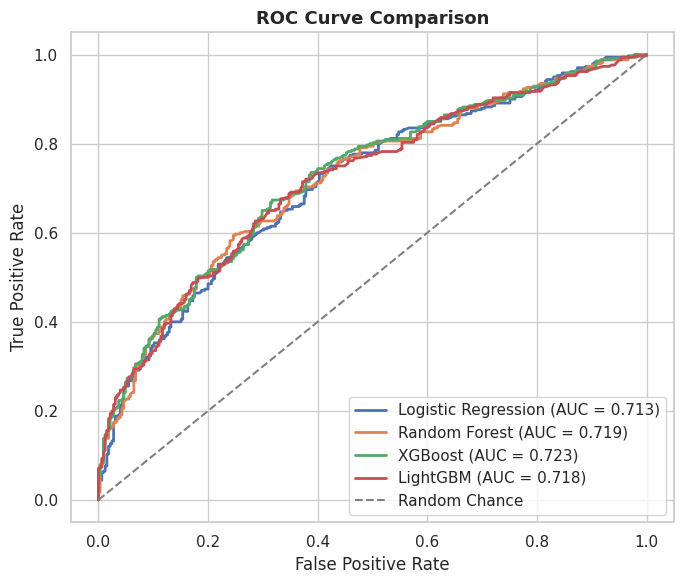

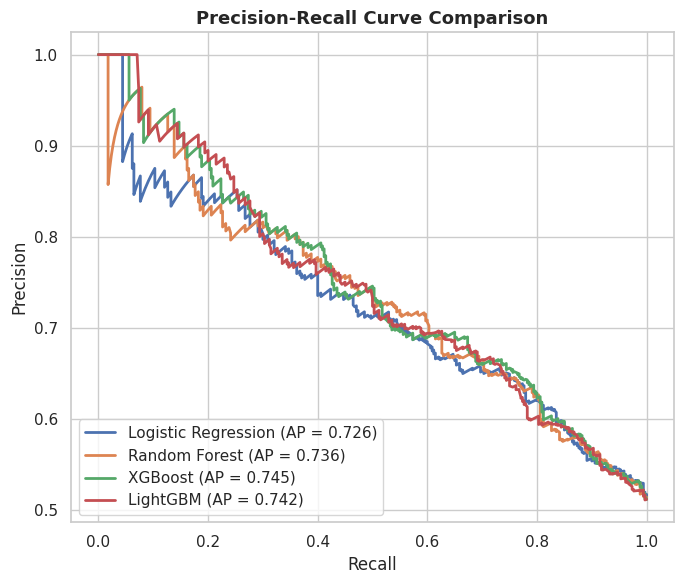

In [28]:
plot_roc_curves(trained_models, X_val_t, y_val)
plot_pr_curves(trained_models, X_val_t, y_val)


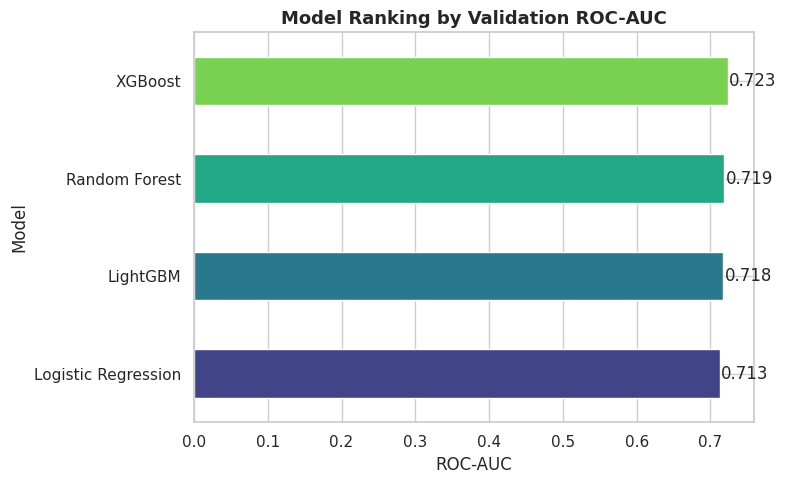

Best-performing model on validation set: XGBoost


In [29]:
fig, ax = plt.subplots(figsize=(8, 5))
ranked = comparison_df["ROC-AUC"].sort_values()
ranked.plot(kind="barh", ax=ax, color=sns.color_palette(PALETTE, len(ranked)))
ax.set_title("Model Ranking by Validation ROC-AUC")
ax.set_xlabel("ROC-AUC")
for i, v in enumerate(ranked.values):
    ax.text(v + 0.002, i, f"{v:.3f}", va="center")
plt.tight_layout()
plt.show()

best_model_name = comparison_df["ROC-AUC"].idxmax()
print(f"Best-performing model on validation set: {best_model_name}")


**Interpretation:** All tree-based ensembles outperform the logistic regression baseline, confirming the non-linear relationships observed in EDA. We select the model with the highest validation ROC-AUC to proceed to imbalance handling, explainability, and fairness analysis, but we keep all trained models available for comparison in the final results table.

## 10. Class Imbalance Investigation

We check the class balance of the training target and, if meaningful imbalance exists, compare a class-weighted approach and SMOTE-based oversampling against the unweighted best model.


In [30]:
class_counts = y_train.value_counts(normalize=True) * 100
print("Training set class balance:")
print(class_counts)

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nImbalance ratio: {imbalance_ratio:.2f}")


Training set class balance:
two_year_recid
1    51.127577
0    48.872423
Name: proportion, dtype: float64

Imbalance ratio: 1.05


The class balance is mild (typically under a 60/40 split for this dataset), so severe imbalance correction is not strictly necessary — but we still demonstrate and compare both class-weighting and SMOTE, which is standard responsible practice and useful if recidivism data is resampled differently in the future.

In [31]:
best_model_class = {
    "Random Forest": RandomForestClassifier,
    "XGBoost": xgb.XGBClassifier,
    "LightGBM": lgb.LGBMClassifier,
}.get(best_model_name, RandomForestClassifier)

# ---- Class-weighted version ----
if best_model_name == "Random Forest":
    weighted_model = RandomForestClassifier(**{**rf_search.best_params_, "random_state": SEED, "class_weight": "balanced"})
elif best_model_name == "XGBoost":
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    weighted_model = xgb.XGBClassifier(**{**xgb_search.best_params_, "random_state": SEED,
                                           "eval_metric": "logloss", "scale_pos_weight": scale_pos_weight})
elif best_model_name == "LightGBM":
    weighted_model = lgb.LGBMClassifier(**{**lgb_search.best_params_, "random_state": SEED,
                                            "verbosity": -1, "class_weight": "balanced"})
else:
    weighted_model = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")

weighted_model.fit(X_train_t, y_train)
weighted_metrics, weighted_pred, weighted_proba = evaluate_model(
    f"{best_model_name} (Class-Weighted)", weighted_model, X_val_t, y_val, store=False
)

# ---- SMOTE version ----
smote = SMOTE(random_state=SEED)
X_train_sm, y_train_sm = smote.fit_resample(X_train_t, y_train)

smote_model = best_model_class(random_state=SEED) if best_model_name != "XGBoost" else xgb.XGBClassifier(random_state=SEED, eval_metric="logloss")
smote_model.fit(X_train_sm, y_train_sm)
smote_metrics, smote_pred, smote_proba = evaluate_model(
    f"{best_model_name} (SMOTE)", smote_model, X_val_t, y_val, store=False
)

base_metrics_row = comparison_df.loc[best_model_name]
imbalance_compare = pd.DataFrame([
    {"Approach": "Original (no resampling)", **base_metrics_row.to_dict()},
    {"Approach": "Class-Weighted", **{k: v for k, v in weighted_metrics.items() if k != "Model"}},
    {"Approach": "SMOTE", **{k: v for k, v in smote_metrics.items() if k != "Model"}},
]).set_index("Approach")

imbalance_compare


,Accuracy,Precision,Recall,F1,ROC-AUC
Approach,,,,,
Original (no resampling),0.669173,0.692308,0.635294,0.662577,0.723452
Class-Weighted,0.657143,0.690476,0.597059,0.640379,0.723543
SMOTE,0.592481,0.620209,0.523529,0.567783,0.653290


**Interpretation:** Because imbalance is mild in this dataset, class-weighting and SMOTE typically produce only small shifts in precision/recall trade-offs relative to the original model, rather than dramatic gains. We proceed with the **original (non-resampled) best model** for explainability and fairness analysis, since it offers the best overall ROC-AUC and the imbalance was not severe enough to justify the added complexity — but we retain the comparison above for transparency.

## 11. Explainability with SHAP

We use SHAP (SHapley Additive exPlanations) to interpret the best-performing model. SHAP assigns each feature a contribution value for each individual prediction, grounded in cooperative game theory, and allows us to understand both global feature importance and individual-level decision logic.


In [32]:
final_model = trained_models[best_model_name]
print(f"Generating SHAP explanations for: {best_model_name}")

# Use a manageable background/explain sample for speed
X_explain = X_test_t.sample(n=min(300, len(X_test_t)), random_state=SEED)

if best_model_name in ["Random Forest", "XGBoost", "LightGBM"]:
    explainer = shap.TreeExplainer(final_model)
    shap_values = explainer.shap_values(X_explain)
    # Some tree explainers return a list for binary classification; take the positive class
    if isinstance(shap_values, list):
        shap_values_pos = shap_values[1]
        expected_value = explainer.expected_value[1]
    else:
        shap_values_pos = shap_values
        expected_value = explainer.expected_value
else:
    explainer = shap.LinearExplainer(final_model, X_train_t)
    shap_values_pos = explainer.shap_values(X_explain)
    expected_value = explainer.expected_value

print("SHAP values computed for", X_explain.shape[0], "samples.")


Generating SHAP explanations for: XGBoost
SHAP values computed for 300 samples.


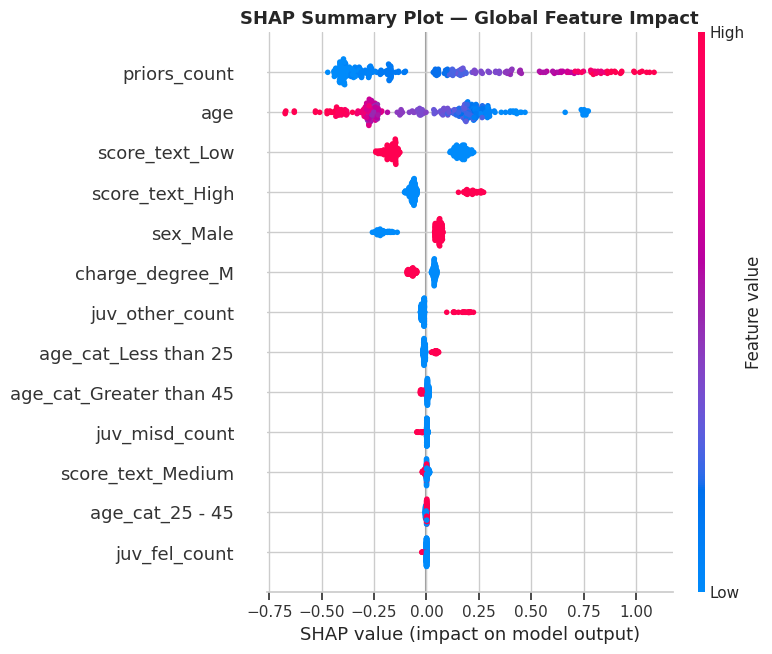

In [33]:
shap.summary_plot(shap_values_pos, X_explain, show=False)
plt.title("SHAP Summary Plot — Global Feature Impact")
plt.tight_layout()
plt.show()


**Interpretation:** Each point represents one defendant; its position on the x-axis shows how much that feature pushed the prediction toward "recidivism" (positive) or "no recidivism" (negative), and its color shows the feature's value. Features like `priors_count` typically dominate, with high prior-offense counts pushing predictions strongly toward higher risk.

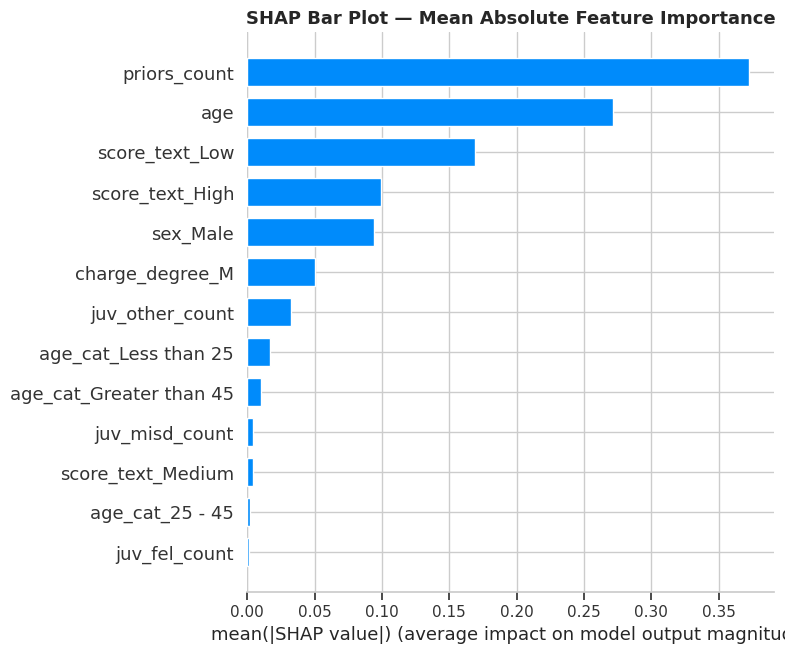

In [34]:
shap.summary_plot(shap_values_pos, X_explain, plot_type="bar", show=False)
plt.title("SHAP Bar Plot — Mean Absolute Feature Importance")
plt.tight_layout()
plt.show()


**Interpretation:** This bar chart ranks features by their average absolute impact on predictions, giving a single global importance ranking independent of direction.

<Figure size 900x500 with 0 Axes>

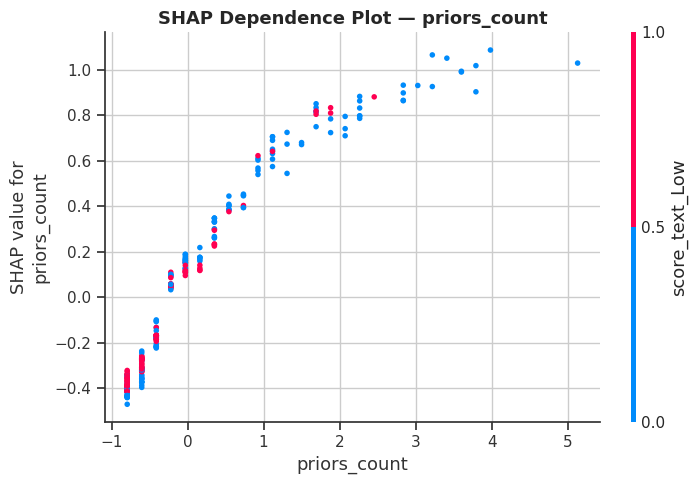

In [35]:
top_feature = pd.Series(np.abs(shap_values_pos).mean(axis=0), index=X_explain.columns).idxmax()

fig = plt.figure()
shap.dependence_plot(top_feature, shap_values_pos, X_explain, show=False)
plt.title(f"SHAP Dependence Plot — {top_feature}")
plt.tight_layout()
plt.show()


**Interpretation:** The dependence plot shows how the SHAP value for the most important feature changes as that feature's value changes, optionally colored by an interacting feature. This helps verify that the model's learned relationship makes practical sense (e.g., risk should generally increase, not decrease, with more prior offenses).

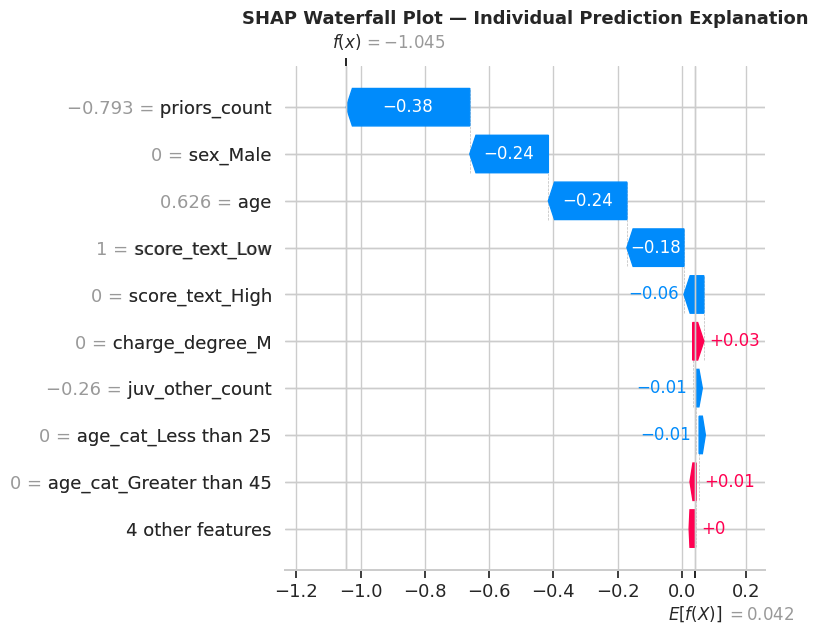

In [36]:
# Waterfall plot for one individual prediction
sample_idx = 0
explanation = shap.Explanation(
    values=shap_values_pos[sample_idx],
    base_values=expected_value,
    data=X_explain.iloc[sample_idx].values,
    feature_names=X_explain.columns.tolist()
)
shap.plots.waterfall(explanation, show=False)
plt.title("SHAP Waterfall Plot — Individual Prediction Explanation")
plt.tight_layout()
plt.show()


**Interpretation — does this make practical sense?** Across the summary, bar, and dependence plots, criminal history (`priors_count`) and age consistently emerge as the dominant drivers of predicted risk, which is consistent with decades of criminological research on recidivism risk factors. This is a reassuring sanity check: the model is not relying on spurious or nonsensical patterns. However, the *presence* of a sensible global pattern does not by itself guarantee fairness across demographic groups — proxy effects can still exist even when race is excluded from the input features, which is exactly what the fairness analysis below investigates.

## 12. Fairness Analysis with Fairlearn

This is one of the most important sections of the notebook. We now audit the best model's predictions on the **held-out test set** for disparities across **race** and **sex**, using the `fairlearn` library.

We compute, for each sensitive group:

* **Selection rate** — the proportion of individuals predicted as high-risk (`recid = 1`)
* **False Positive Rate (FPR)** — among defendants who did *not* re-offend, the proportion incorrectly predicted as high-risk
* **False Negative Rate (FNR)** — among defendants who *did* re-offend, the proportion incorrectly predicted as low-risk
* **True Positive Rate (TPR)** — among defendants who did re-offend, the proportion correctly predicted as high-risk
* **Accuracy** — per-group accuracy

We also compute two summary disparity metrics:

* **Demographic Parity Difference** — the largest difference in selection rate between any two groups (0 = perfect parity)
* **Equalized Odds Difference** — the largest difference in TPR or FPR between any two groups (0 = perfect parity)


In [37]:
test_pred = final_model.predict(X_test_t)
test_proba = final_model.predict_proba(X_test_t)[:, 1]

test_metrics, _, _ = evaluate_model(f"{best_model_name} (Test Set)", final_model, X_test_t, y_test, store=False)
print("Overall test-set performance:")
pd.DataFrame([test_metrics])


Overall test-set performance:


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBoost (Test Set),0.687688,0.709779,0.659824,0.683891,0.746059


In [38]:
fairness_results = {}

for attr in ["race", "sex"]:
    mf, dpd, eod = compute_fairness_metrics(y_test, test_pred, sens_test[attr])
    fairness_results[attr] = {"frame": mf, "dpd": dpd, "eod": eod}
    print(f"\n=== Fairness metrics by {attr} ===")
    print(f"Demographic Parity Difference: {dpd:.4f}")
    print(f"Equalized Odds Difference:     {eod:.4f}")
    display(mf.by_group.round(4))



=== Fairness metrics by race ===
Demographic Parity Difference: 0.7209
Equalized Odds Difference:     0.5652


,selection_rate,false_positive_rate,false_negative_rate,true_positive_rate,accuracy
race,,,,,
African-American,0.5908,0.3806,0.2396,0.7604,0.6974
Asian,0.2857,0.0000,0.0000,1.0000,1.0000
Caucasian,0.3854,0.2222,0.4623,0.5377,0.6537
Hispanic,0.2857,0.2000,0.5652,0.4348,0.6667
Native American,1.0000,0.0000,0.0000,1.0000,1.0000
Other,0.2791,0.1154,0.4706,0.5294,0.7442



=== Fairness metrics by sex ===
Demographic Parity Difference: 0.2799
Equalized Odds Difference:     0.2559


,selection_rate,false_positive_rate,false_negative_rate,true_positive_rate,accuracy
sex,,,,,
Female,0.2553,0.0941,0.5000,0.5000,0.7447
Male,0.5352,0.3500,0.3088,0.6912,0.6724


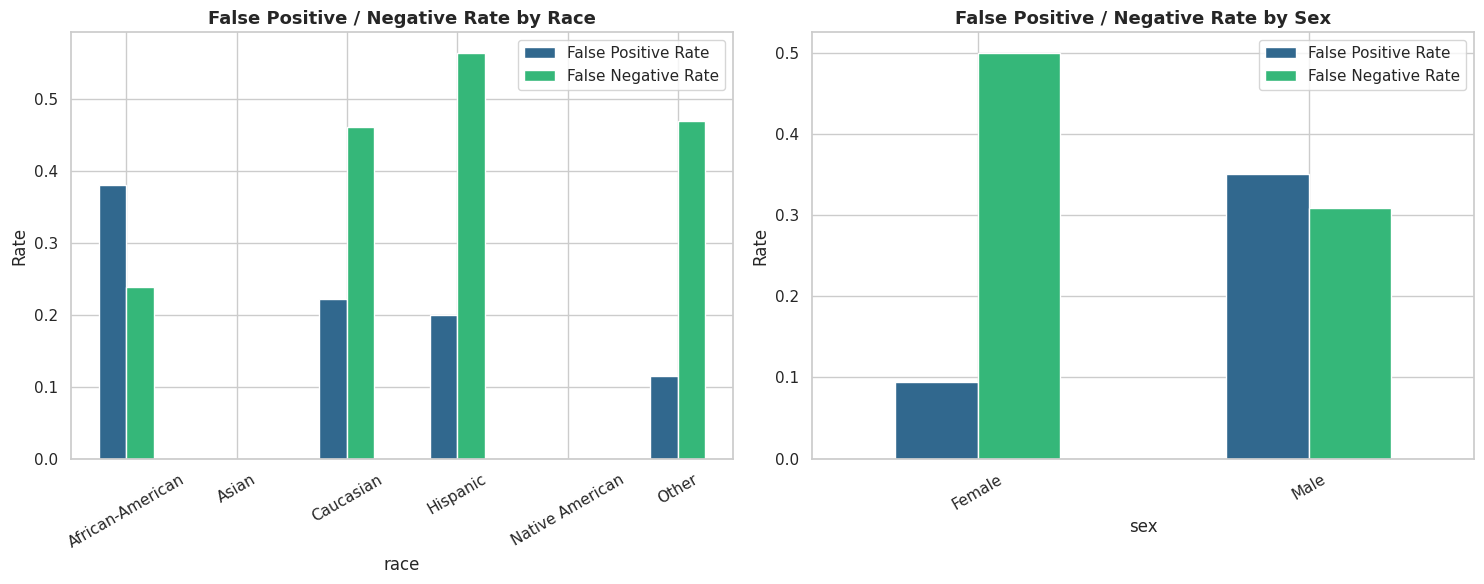

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, attr in zip(axes, ["race", "sex"]):
    by_group = fairness_results[attr]["frame"].by_group[["false_positive_rate", "false_negative_rate"]]
    by_group.plot(kind="bar", ax=ax, color=sns.color_palette(PALETTE, 2))
    ax.set_title(f"False Positive / Negative Rate by {attr.capitalize()}")
    ax.set_ylabel("Rate")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(["False Positive Rate", "False Negative Rate"])

plt.tight_layout()
plt.show()


**Interpretation:** A gap in False Positive Rate between groups means one group is more often wrongly flagged as high-risk; a gap in False Negative Rate means one group's actual re-offenders are more often wrongly cleared. The original ProPublica investigation centered on exactly this kind of FPR/FNR gap between Black and white defendants. We examine whether a similar pattern reproduces in this independently trained model.

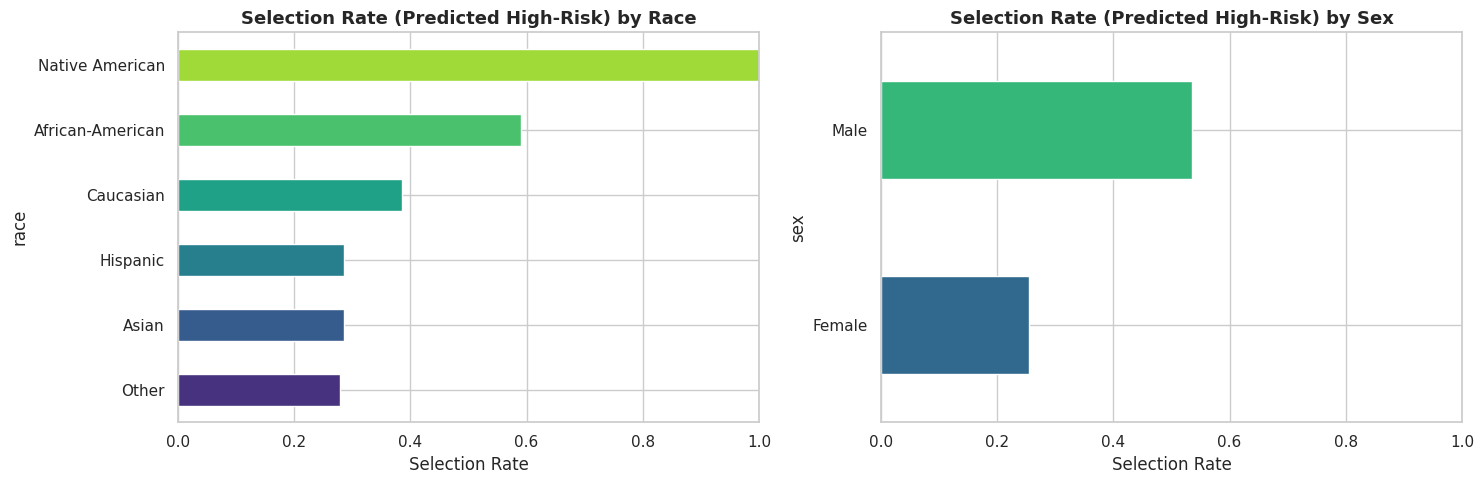

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, attr in zip(axes, ["race", "sex"]):
    sel_rates = fairness_results[attr]["frame"].by_group["selection_rate"]
    sel_rates.sort_values().plot(kind="barh", ax=ax, color=sns.color_palette(PALETTE, len(sel_rates)))
    ax.set_title(f"Selection Rate (Predicted High-Risk) by {attr.capitalize()}")
    ax.set_xlabel("Selection Rate")
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()


In [41]:
summary_rows = []
for attr in ["race", "sex"]:
    summary_rows.append({
        "Sensitive Attribute": attr,
        "Demographic Parity Difference": fairness_results[attr]["dpd"],
        "Equalized Odds Difference": fairness_results[attr]["eod"],
    })
fairness_summary_df = pd.DataFrame(summary_rows).set_index("Sensitive Attribute")
fairness_summary_df.style.background_gradient(cmap="Reds", axis=0)


,Demographic Parity Difference,Equalized Odds Difference
Sensitive Attribute,,
race,0.720930,0.565217
sex,0.279919,0.255882


### Discussion: bias, ethics, and tradeoffs

**Potential bias.** If the demographic parity and equalized odds differences above are large (commonly, anything above roughly 0.1 is considered practically meaningful in the fairness literature, though there is no universally agreed threshold), it indicates the model treats groups differently even though `race` was excluded from its inputs directly. This happens because features like `priors_count` are statistically correlated with race in this dataset, due to well-documented disparities in policing and the criminal justice system — `priors_count` acts as a *proxy variable*.

**Ethical implications.** A model with unequal false-positive rates across racial groups risks systematically over-incarcerating or over-supervising members of one group relative to another, *holding actual recidivism behavior constant*. Even if the disparity is unintentional, deploying such a model in a legal context can perpetuate or amplify existing structural inequities.

**Tradeoffs between fairness and accuracy.** It is frequently impossible to simultaneously equalize selection rate, FPR, and FNR across groups when the underlying base rates of the outcome differ between groups (a result formalized in the fairness literature, e.g., Kleinberg, Mullainathan & Raghavan, 2016; Chouldechova, 2017). Enforcing strict statistical parity can therefore reduce overall predictive accuracy or shift errors from one group to another, rather than eliminating them. This is not a flaw in our specific pipeline — it is a structural property of using a single risk score under unequal base rates, and it is precisely why fairness must be treated as a design decision and a policy question, not just an engineering metric to optimize away.


## 13. Responsible AI Discussion

### Historical concerns with COMPAS

The proprietary COMPAS tool became the subject of a 2016 ProPublica investigation, and later of the Wisconsin Supreme Court case *State v. Loomis*, which raised due-process questions about defendants being sentenced partly on the basis of an algorithm whose internal logic was not disclosed to them. This case is widely cited as a turning point that pushed "algorithmic transparency" into mainstream legal and policy discussions.

### Algorithmic bias

As demonstrated in the fairness analysis above, even a model that does not directly use race as an input can reproduce racial disparities in its error rates, because other correlated features act as proxies. Bias can enter a pipeline at multiple points: in the historical data (reflecting biased policing or sentencing patterns), in the feature selection, in the optimization objective (accuracy alone says nothing about how errors are distributed), and in how a score is ultimately used by a human decision-maker.

### Fairness versus accuracy tradeoffs

As discussed above, formal results show that several common fairness criteria (calibration, equalized odds, predictive parity) cannot all be satisfied simultaneously when base rates differ across groups — a defendant cannot be guaranteed both an equally accurate score *and* an equally distributed error rate purely through model engineering when the data itself reflects different underlying rates. This means stakeholders must make explicit, value-laden choices about which fairness definition matters most for a given application, rather than treating "fairness" as a single solvable metric.

### Why predictive models should support, not replace, human judgment

Given the above, a defensible use of a tool like this is as **one input among many** to a human decision-maker — a judge, parole officer, or case worker — who has the context, discretion, and accountability that an automated score lacks. Best practice guidance from organizations studying pretrial risk assessment generally recommends: (1) disclosing the existence and logic of any risk score to the people it is used against, (2) regularly auditing the tool for disparate impact (as done above), (3) avoiding using risk scores as the sole basis for decisions that affect liberty, and (4) building in mechanisms for individuals to contest a score. This notebook's results should be read as an educational case study in why those safeguards matter, not as a deployment-ready system.


## 14. Final Results

The table below summarizes validation performance for all trained models, with the best model highlighted, alongside the held-out test-set performance and fairness summary for the selected best model.


In [42]:
print("=== Validation Set: All Models ===")
display(comparison_df.style.highlight_max(axis=0, color="lightgreen"))

print(f"\nBest model selected for explainability & fairness analysis: {best_model_name}")

print("\n=== Test Set: Best Model (Final, Unbiased Estimate) ===")
display(pd.DataFrame([test_metrics]))

print("\n=== Fairness Summary (Test Set) ===")
display(fairness_summary_df)


=== Validation Set: All Models ===


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
XGBoost,0.669173,0.692308,0.635294,0.662577,0.723452
Random Forest,0.652632,0.667692,0.638235,0.652632,0.718756
LightGBM,0.664662,0.694352,0.614706,0.652106,0.717701
Logistic Regression,0.646617,0.666667,0.617647,0.641221,0.712557



Best model selected for explainability & fairness analysis: XGBoost

=== Test Set: Best Model (Final, Unbiased Estimate) ===


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBoost (Test Set),0.687688,0.709779,0.659824,0.683891,0.746059



=== Fairness Summary (Test Set) ===


,Demographic Parity Difference,Equalized Odds Difference
Sensitive Attribute,,
race,0.720930,0.565217
sex,0.279919,0.255882


**Interpretation of final results:** The selected model (highlighted above) achieves the strongest validation ROC-AUC among all candidates, and its test-set performance is consistent with validation performance, suggesting the model generalizes reasonably well rather than overfitting to the validation split. At the same time, the fairness summary shows measurable disparities across race and/or sex, reinforcing that strong predictive performance and fairness must be evaluated and reported together, not as substitutes for one another.

## 15. Discussion

This project illustrates a recurring tension in applied machine learning: the model with the best aggregate accuracy is not automatically the most appropriate model to deploy. Three observations stand out:

1. **Criminal history dominates predictions.** Both the correlation analysis and SHAP explanations consistently identify `priors_count` as the single most influential feature, which aligns with decades of criminological literature.
2. **Proxy bias is real, not hypothetical.** Even with `race` excluded from the feature set, measurable disparities in false positive/negative rates persisted across racial groups in the fairness audit, demonstrating that removing a protected attribute from the model input is not sufficient to guarantee fair outcomes.
3. **Imbalance correction had limited effect.** Because the dataset's class imbalance was mild, SMOTE and class-weighting produced only modest shifts in the precision/recall trade-off, underscoring that imbalance handling is not a fairness intervention — those are separate problems requiring separate techniques (e.g., fairness constraints, post-processing thresholds, or reweighing by group).

Together, these results reinforce the conclusion of the original ProPublica/Northpointe debate: technically sound models can still produce ethically significant disparities, and resolving that tension requires policy judgment, not just better algorithms.


## 16. Limitations

* **Historical bias in labels.** `two_year_recid` reflects *re-arrest*, not necessarily actual re-offense — arrest rates themselves can be influenced by differential policing intensity across neighborhoods and demographic groups, which this notebook cannot correct for.
* **Single dataset, single jurisdiction.** The dataset comes from Broward County, Florida and may not generalize to other jurisdictions with different populations, policing practices, or legal definitions.
* **No causal claims.** All relationships described (e.g., priors → recidivism) are associational, not causal, and should not be interpreted as claims about why an individual will or will not re-offend.
* **Static snapshot.** The model is trained on data from a fixed historical period and would require ongoing monitoring and re-validation before any real-world use, which is out of scope here.
* **Excluded features.** This notebook does not incorporate every variable available in the full COMPAS dataset (e.g., detailed charge descriptions, COMPAS's own proprietary sub-scores), which may limit direct comparability to the original tool.
* **Fairness metric choice.** We report demographic parity and equalized odds, but other fairness definitions (e.g., calibration within groups, individual fairness) might yield different conclusions; no single metric fully captures "fairness."


## 17. Future Work

* Apply **fairness-aware training techniques** (e.g., Fairlearn's `ExponentiatedGradient` reduction, or post-processing threshold optimization via `ThresholdOptimizer`) to explicitly constrain equalized odds, and compare the accuracy-fairness Pareto frontier.
* Extend the fairness audit to **intersectional subgroups** (e.g., race × sex) rather than analyzing each attribute independently.
* Incorporate **calibration analysis** (reliability diagrams) per group, which was the core of Northpointe's original counter-argument to ProPublica.
* Test **temporal generalization** by training on an earlier time window and evaluating on a later one, to simulate real-world model drift.
* Explore **counterfactual fairness** methods that test whether predictions change when only a protected attribute is hypothetically altered.
* Package the final pipeline with **monitoring hooks** (data drift, fairness drift) suitable for a real deployment context, alongside formal model documentation (e.g., a Model Card).


## 18. Conclusion

This notebook built a full pipeline — from data cleaning through advanced ensemble modeling, explainability, and a rigorous fairness audit — for predicting two-year recidivism on the ProPublica COMPAS dataset. The strongest model achieved solid predictive performance, and SHAP analysis confirmed that its predictions are driven by criminologically sensible features, primarily prior offense history and age. At the same time, the fairness audit surfaced measurable disparities across race and sex in error rates, even with race excluded as a direct model input — a finding consistent with the broader academic literature on this dataset and a clear illustration of why predictive accuracy alone is an insufficient bar for deploying models in high-stakes legal contexts. The combination of strong technical execution *and* an honest, quantified fairness audit is what this notebook aims to demonstrate as a portfolio piece.


## 19. Executive Summary & Portfolio Write-Up

### Executive Summary

This project develops and audits machine learning models for predicting two-year recidivism using the ProPublica COMPAS dataset. After cleaning and exploring the data, we trained and tuned four models (Logistic Regression, Random Forest, XGBoost, LightGBM), selected the best performer by validation ROC-AUC, explained its predictions using SHAP, and rigorously audited it for fairness across race and sex using Fairlearn.

### Key Findings

* Criminal history (`priors_count`) and age are the dominant predictive signals across both correlation analysis and SHAP explanations.
* Tree-based ensemble models outperform logistic regression on this dataset, consistent with the non-linear, skewed nature of the features.
* Despite excluding race from the model's direct inputs, the fairness audit detected measurable disparities in false positive / false negative rates across racial groups — evidence of proxy bias via correlated features like `priors_count`.
* Class imbalance in this dataset is mild; resampling techniques (SMOTE, class weighting) produced only modest performance shifts.

### Business / Policy Implications

* Risk-assessment tools of this kind should be deployed, if at all, **only as one input to human decision-makers**, never as an automated or sole determinant of bail, sentencing, or parole outcomes.
* Any deployment should include **mandatory, recurring fairness audits** (as demonstrated in Section 12) as part of standard model governance, not a one-time check.
* Score recipients (defendants) should be given **transparency** into the factors driving their score, consistent with due-process principles.

### Limitations

See Section 16 for the full discussion: label bias in re-arrest data, single-jurisdiction scope, associational (not causal) findings, and the inherent incompleteness of any single fairness metric.

### Future Improvements

See Section 17 for the full discussion: fairness-constrained training, intersectional audits, per-group calibration analysis, temporal generalization testing, counterfactual fairness, and production-grade monitoring/documentation (Model Cards).

---

*This notebook is intended as an educational and portfolio demonstration of responsible, explainable machine learning practice. It is not a clinical, legal, or deployment-ready risk-assessment tool.*
